In [1]:
# IMPORTS
import numpy as np
from joblib import Parallel, delayed
from scipy.integrate import odeint
from scipy.stats import genextreme as gev
from numba import njit
import matplotlib.pyplot as plt
from pyextremes import EVA
import pandas as pd

#%config InlineBackend.figure_format="pdf"

In [2]:
# CODE FROM ROBIN NOYELLE (Dynamical System + an implementation of simple boosting)
class DynamicalSystem:
    """
    DynamicalSystem
    ====================
    Class to represent and integrate the dynamical system.
    """

    def __init__(self, f, stochastic, sigma, step, *args):
        self.drift = njit(f)
        self.drift_args = args
        self.stochastic = stochastic
        self.sigma = sigma
        self.step = step

    @staticmethod
    @njit
    def _integrate_stochastic(drift, state0, times, step, sigma, *args):
        n = state0.size
        n_T = times.size
        result = np.zeros((n_T, n))
        result[0, :] = state0

        for i in range(n_T - 1):
            I_k = np.sqrt(step) * np.random.normal(loc=0, scale=1, size=n)
            zeta_k = np.sqrt(step) * np.random.normal(loc=0, scale=1, size=n)
            I_k0 = 0.5 * step * (I_k + 1.0 / np.sqrt(3) * zeta_k)

            a_H1 = drift(result[i, :], times[i], *args)
            a_H2 = drift(result[i, :] + a_H1 * step, times[i] + step, *args)
            a_H3 = drift(
                result[i, :]
                + (0.25 * a_H1 + 0.25 * a_H2) * step
                + sigma * 3.0 / 2.0 * I_k0 / step,
                times[i] + step * 0.5,
                *args,
            )

            result[i + 1, :] = (
                result[i, :]
                + (1.0 / 6.0 * a_H1 + 1.0 / 6.0 * a_H2 + 2.0 / 3.0 * a_H3) * step
                + sigma * I_k
            )

        return result

    def _integration(self, state0, times):
        if self.stochastic:
            return self._integrate_stochastic(
                self.drift, state0, times, self.step, self.sigma, *self.drift_args
            )
        else:
            return odeint(self.drift, state0, times)

    def run_trajectory(self, state0, t_0, t_1):
        times = np.linspace(t_0, t_1, round((t_1 - t_0) / self.step) + 1)
        return self._integration(state0, times)

    def run_trajectories(self, starting_points, t_0, t_1, n_jobs):
        trajectories_computed = np.array(
            Parallel(n_jobs=n_jobs)(
                delayed(self.run_trajectory)(state0, t_0, t_1)
                for state0 in starting_points
            )
        )
        return trajectories_computed


def f_langevin(x, t, alpha):
    return -alpha * x


# FUNCTIONS FOR SIMPLE AND ITERATIVE BOOSTING


def extract_antecedent_conditions_from_peak(trajectories, indices, t_lead, step):
    """Phase 1: go back t_lead from the PEAK of a historical trajectory."""
    lead_steps = int(t_lead / step)
    AC = []
    for idx in indices:
        traj = trajectories[idx]
        peak_idx = np.argmax(traj)
        start_idx = max(0, peak_idx - lead_steps)
        AC.append(traj[start_idx])
    return np.array(AC)


def extract_antecedent_conditions_from_end(trajectories, indices, t_lead, step):
    """Phase >1: go back t_lead from the END of the previous phase's trajectory."""
    lead_steps = int(t_lead / step)
    AC = []
    for idx in indices:
        traj = trajectories[idx]
        start_idx = max(0, len(traj) - 1 - lead_steps)
        AC.append(traj[start_idx])
    return np.array(AC)


def bootstrap_confidence_intervals(maxes, valid_maxes, P_Tref, Tref, n_boot=1000):
    """Calculate 95% CI bounds using bootstrapping on the generated maxima array."""
    n = len(maxes)
    rt_boots = np.zeros((n_boot, len(valid_maxes)))

    for i in range(n_boot):
        boot = np.random.choice(maxes, size=n, replace=True)
        p_tref_ac = np.mean(boot >= Tref)
#        if p_tref_ac == 0:
#            p_tref_ac = 1.0 / n

        boot_sorted = np.sort(boot)
        # fast vectorized count of elements >= v
        counts = n - np.searchsorted(boot_sorted, valid_maxes, side="left")
        p_ext_ac = counts / n
        p_ext_ac = np.where(p_ext_ac == 0, np.nan, p_ext_ac) #prevents /0 for when bootstrap doesn't have the T_ext

        probs = P_Tref * (p_ext_ac / p_tref_ac)
        rt_boots[i, :] = 1.0 / probs

    ci_lower = np.nanpercentile(rt_boots, 2.5, axis=0)
    ci_upper = np.nanpercentile(rt_boots, 97.5, axis=0)
    return ci_lower, ci_upper


def run_simple_boosting_ou(
    control_trajectories,
    ds,
    step,
    N_batch_total=30,
    t_lead=0.2,
    t_forward=1.0,
    Tref_0=None,
):
    """Standard Simple Boosting (Single Phase)."""
    control_maxes = np.array([np.max(traj) for traj in control_trajectories])

    P_Tref_0 = np.mean(control_maxes >= Tref_0)
    parent_indices = np.where(control_maxes >= Tref_0)[0]

    AC = extract_antecedent_conditions_from_peak(
        control_trajectories, parent_indices, t_lead, step
    )

    forward_steps = int(t_forward / step)
    starting_points = np.repeat(AC, N_batch_total, axis=0)
    starting_points += np.random.normal(0, 1e-10, starting_points.shape)

    trajectories = ds.run_trajectories(starting_points, 0, t_forward, n_jobs=-1)
    cost_steps = len(starting_points) * forward_steps

    maxes = np.max(trajectories, axis=(1, 2))

    P_Tref_0_AC = np.mean(maxes >= Tref_0)
#    if P_Tref_0_AC == 0:
#        P_Tref_0_AC = 1 / len(maxes)

    valid_maxes = maxes[maxes >= Tref_0]
    sorted_maxes = np.sort(valid_maxes)[::-1]

    probs_cond = np.arange(1, len(valid_maxes) + 1) / len(maxes)
    probs = P_Tref_0 * (probs_cond / P_Tref_0_AC)
    return_times = 1 / probs

    # bootstrap
    ci_lower, ci_upper = bootstrap_confidence_intervals(
        maxes, sorted_maxes, P_Tref_0, Tref_0
    )

    return sorted_maxes, return_times, ci_lower, ci_upper, cost_steps


def run_iterative_boosting_ou(
    control_trajectories,
    ds,
    step,
    J=3,
    q=0.1,
    N_batch=10,
    t_leads=[0.2, 0.2, 0.2],
    t_forwards=[0.4, 0.4, 0.6],
    Tref_0=None,
):
    """Iterative Boosting over J phases with variable leads and forwards."""
    control_maxes = np.array([np.max(traj) for traj in control_trajectories])

    P_Tref_0 = np.mean(control_maxes >= Tref_0)
    parent_indices = np.where(control_maxes >= Tref_0)[0]

    current_AC = extract_antecedent_conditions_from_peak(
        control_trajectories, parent_indices, t_leads[0], step
    )

    current_P_Tref = P_Tref_0
    current_Tref = Tref_0
    cost_steps = 0

    # iterate for J-1 phases
    for j in range(J - 1):
        t_forward = t_forwards[j]
        forward_steps = int(t_forward / step)

        starting_points = np.repeat(current_AC, N_batch, axis=0)
        starting_points += np.random.normal(0, 1e-10, starting_points.shape)

        trajectories = ds.run_trajectories(starting_points, 0, t_forward, n_jobs=-1)
        cost_steps += len(starting_points) * forward_steps
        maxes = np.max(trajectories, axis=(1, 2))

        P_Tref_prev_AC = np.mean(maxes >= current_Tref)
#        if P_Tref_prev_AC == 0:
#            P_Tref_prev_AC = 1 / len(maxes)

        n_keep = int(np.round(q * len(maxes)))
        sorted_idx = np.argsort(maxes)[::-1]
        keep_idx = sorted_idx[:n_keep]
        next_Tref = maxes[keep_idx[-1]]

        current_P_Tref = current_P_Tref * (q / P_Tref_prev_AC)
        current_Tref = next_Tref

        current_AC = extract_antecedent_conditions_from_end(
            trajectories, keep_idx, t_leads[j + 1], step
        )

    # final phase J
    t_forward = t_forwards[-1]
    forward_steps = int(t_forward / step)

    starting_points = np.repeat(current_AC, N_batch, axis=0)
    starting_points += np.random.normal(0, 1e-10, starting_points.shape)

    trajectories = ds.run_trajectories(starting_points, 0, t_forward, n_jobs=-1)
    cost_steps += len(starting_points) * forward_steps
    maxes = np.max(trajectories, axis=(1, 2))

    P_Tref_prev_AC = np.mean(maxes >= current_Tref)
#    if P_Tref_prev_AC == 0:
#        P_Tref_prev_AC = 1 / len(maxes)

    valid_maxes = maxes[maxes >= current_Tref]
    sorted_maxes = np.sort(valid_maxes)[::-1]

    probs_cond = np.arange(1, len(valid_maxes) + 1) / len(maxes)
    probs = current_P_Tref * (probs_cond / P_Tref_prev_AC)
    return_times = 1 / probs

    # bootstrap
    ci_lower, ci_upper = bootstrap_confidence_intervals(
        maxes, sorted_maxes, current_P_Tref, current_Tref
    )

    return sorted_maxes, return_times, ci_lower, ci_upper, cost_steps

In [3]:
alpha, sigma, step = 1.0, 1.0, 0.01
ou_system = DynamicalSystem(f_langevin, True, sigma, step, alpha)
t_control = 3.0

In [4]:
# long control run (Ground Truth)
N_long = 1_500_000
print(f"Generating Long Control ({N_long:,} simulations)...")
starting_points_long = np.random.normal(0, np.sqrt(sigma**2 / (2 * alpha)), (N_long, 1))
long_trajectories = ou_system.run_trajectories(
    starting_points_long, 0.0, t_control, n_jobs=-1
)

long_maxes = np.sort(np.max(long_trajectories, axis=(1, 2)))[::-1]
rt_long = 1 / (np.arange(1, N_long + 1) / N_long)

Generating Long Control (1,500,000 simulations)...


In [5]:
# short control run (for parent selection too)
N_short = 200
print(f"Generating Short Control ({N_short:,} simulations)...")
starting_points_short = np.random.normal(
    0, np.sqrt(sigma**2 / (2 * alpha)), (N_short, 1)
)
short_trajectories = ou_system.run_trajectories(
    starting_points_short, 0.0, t_control, n_jobs=-1
)

short_maxes = np.sort(np.max(short_trajectories, axis=(1, 2)))[::-1]
rt_short = 1 / (np.arange(1, N_short + 1) / N_short)

# baseline threshold
q_init=0.1
Tref_0 = np.quantile(short_maxes, 1-q_init)

Generating Short Control (200 simulations)...


In [6]:
# fit gev
print("Fitting GEV to Short Control...")
gev_rt = np.logspace(0.1, 6, 200)

#dummy dates
dates = pd.date_range(start="2000-01-01", periods=len(short_maxes), freq="365D")
ts = pd.Series(short_maxes, index=dates)

model = EVA(data=ts)
model.get_extremes(method="BM", extremes_type="high", block_size="365D")
model.fit_model(model="Emcee")

gev_levels, gev_ci_lower, gev_ci_upper = model.get_return_value(
    return_period=gev_rt, 
    return_period_size="365D", 
    alpha=0.95
)

Fitting GEV to Short Control...


Running Simple Boosting (1 Phase)...
Running Iterative Boosting (3 Phases)...

--- Cost & Performance Analysis ---
Naive Monte Carlo Cost: 60,000 steps | Max Magnitude: 3.04
Simple Boosting Cost:   56,000 steps | Max Magnitude: 3.10
Iterative Boosting Cost:56,000 steps | Max Magnitude: 3.78

[Cost per unit of Return Time]
Naive Monte Carlo:  300.0000 steps/year
Simple Boosting:    22.0472 steps/year
Iterative Boosting: 0.6185 steps/year

[Performance Upgrades]
Naive to Simple Boosting:      13.6x more efficient
Naive to Iterative Boosting:   485.0x more efficient
Simple to Iterative Boosting:  35.6x more efficient


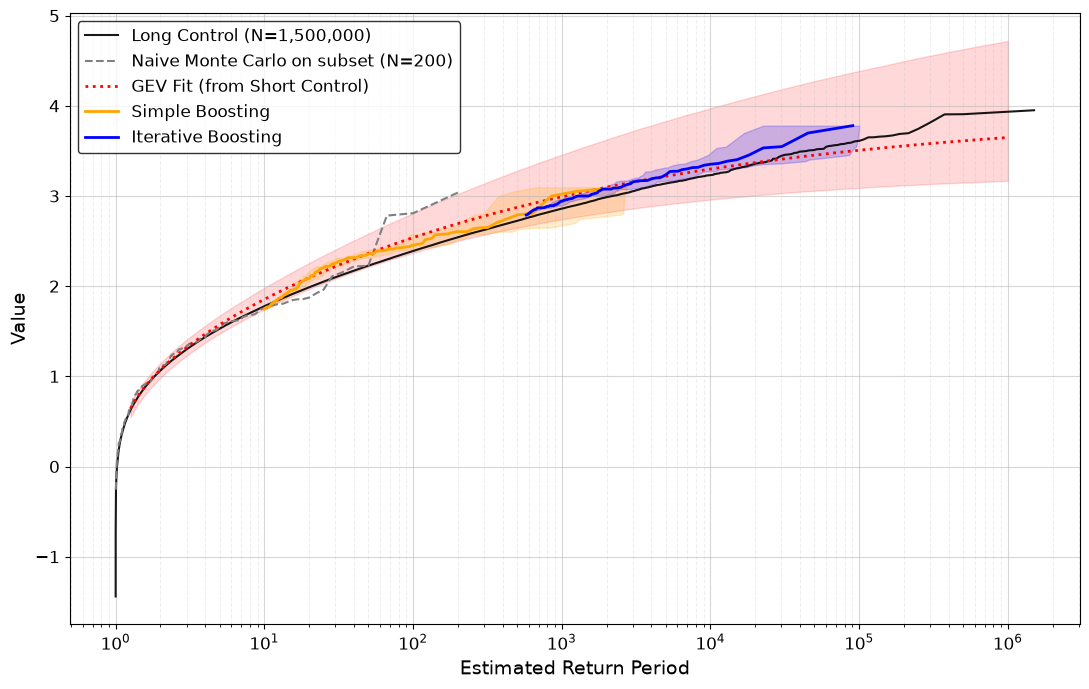

In [14]:
q=0.05
N_batch=int(1/q)
# simple boosting
print("Running Simple Boosting (1 Phase)...")
sb_maxes, sb_rt, sb_ci_low, sb_ci_high, cost_sb = run_simple_boosting_ou(
    short_trajectories,
    ou_system,
    step,
    N_batch_total=1.4*N_batch,
    t_lead=0.2,
    t_forward=1.0,
    Tref_0=Tref_0,
)

# 3 phases iterative boosting
t_leads_iter = [0.2, 0.2, 0.2]
t_forwards_iter = [0.4, 0.4, 0.6]

print("Running Iterative Boosting (3 Phases)...")
ib_maxes, ib_rt, ib_ci_low, ib_ci_high, cost_ib = run_iterative_boosting_ou(
    short_trajectories,
    ou_system,
    step,
    J=3,
    q=q,
    N_batch=N_batch,
    t_leads=t_leads_iter,
    t_forwards=t_forwards_iter,
    Tref_0=Tref_0,
)

# COSTS
cost_short_control = N_short * int(t_control / step)
naive_cost_efficiency = cost_short_control / rt_short.max()
sb_cost_efficiency = cost_sb / sb_rt.max()
ib_cost_efficiency = cost_ib / ib_rt.max()

upgrade_naive_to_sb = naive_cost_efficiency / sb_cost_efficiency
upgrade_naive_to_ib = naive_cost_efficiency / ib_cost_efficiency
upgrade_sb_to_ib = sb_cost_efficiency / ib_cost_efficiency

print("\n--- Cost & Performance Analysis ---")
print(f"Naive Monte Carlo Cost: {cost_short_control:,} steps | Max Magnitude: {short_maxes[0]:.2f}")
print(f"Simple Boosting Cost:   {cost_sb:,} steps | Max Magnitude: {sb_maxes[0]:.2f}")
print(f"Iterative Boosting Cost:{cost_ib:,} steps | Max Magnitude: {ib_maxes[0]:.2f}")

print("\n[Cost per unit of Return Time]")
print(f"Naive Monte Carlo:  {naive_cost_efficiency:.4f} steps/year")
print(f"Simple Boosting:    {sb_cost_efficiency:.4f} steps/year")
print(f"Iterative Boosting: {ib_cost_efficiency:.4f} steps/year")

print("\n[Performance Upgrades]")
print(f"Naive to Simple Boosting:      {upgrade_naive_to_sb:.1f}x more efficient")
print(f"Naive to Iterative Boosting:   {upgrade_naive_to_ib:.1f}x more efficient")
print(f"Simple to Iterative Boosting:  {upgrade_sb_to_ib:.1f}x more efficient")

#PLOTS

plt.figure(figsize=(11, 7))

# ground truth and naive
plt.plot(
    rt_long,
    long_maxes,
    color="black",
    linestyle="-",
    lw=1.5,
    alpha=0.9,
    label=f"Long Control (N={N_long:,})",
)
plt.plot(
    rt_short,
    short_maxes,
    color="gray",
    linestyle="--",
    lw=1.5,
    label=f"Naive Monte Carlo on subset (N={N_short:,})",
)

# GEV
plt.plot(
    gev_rt,
    gev_levels,
    color="red",
    linestyle=":",
    lw=2,
    label="GEV Fit (from Short Control)",
)
plt.fill_between(gev_rt, gev_ci_lower, gev_ci_upper, color="red", alpha=0.15)

# Simple boosting
plt.plot(sb_rt, sb_maxes, color="orange", linestyle="-", lw=2, label="Simple Boosting")
plt.fill_betweenx(sb_maxes, sb_ci_low, sb_ci_high, color="orange", alpha=0.2)

# Iterative boosting
plt.plot(ib_rt, ib_maxes, color="blue", linestyle="-", lw=2, label="Iterative Boosting")
plt.fill_betweenx(ib_maxes, ib_ci_low, ib_ci_high, color="blue", alpha=0.2)

plt.xscale("log")
plt.xlabel("Estimated Return Period", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(True, which="major", linestyle="-", alpha=0.5)
plt.grid(True, which="minor", linestyle="--", alpha=0.2)
plt.legend(fontsize=12, frameon=True, edgecolor="black")

plt.tight_layout()
plt.savefig("return_times_OU.pdf",bbox_inches="tight")
plt.show()